In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## General Code for Gradient Descent

Initial x: 1.0
Iteration 0: x = 0.200000, g(x) = 0.040000
Iteration 1: x = 0.040000, g(x) = 0.001600
Iteration 2: x = 0.008000, g(x) = 0.000064
Iteration 3: x = 0.001600, g(x) = 0.000003
Iteration 4: x = 0.000320, g(x) = 0.000000
Iteration 5: x = 0.000064, g(x) = 0.000000
Iteration 6: x = 0.000013, g(x) = 0.000000
Iteration 7: x = 0.000003, g(x) = 0.000000
Iteration 8: x = 0.000001, g(x) = 0.000000
Iteration 9: x = 0.000000, g(x) = 0.000000

Optimal x (approx) :  1.023999999999997e-07


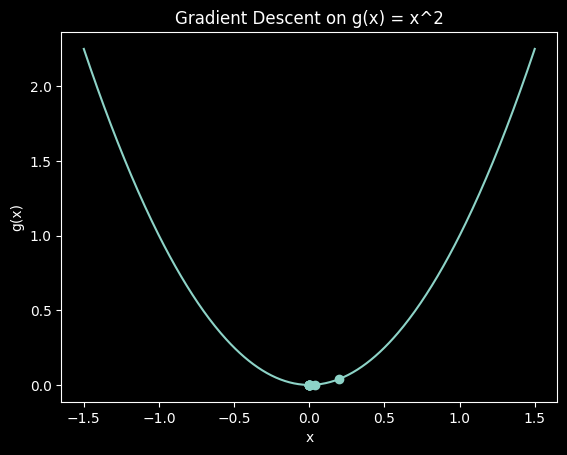

In [6]:
#Gradient Descent

#Objective function
def g(x):
    return x**2

#Derivative/Gradient of objective function
def grad_g(x):
    return 2*x

#Initialization
x = 1.0        # x0 = 1
eta = 0.4      # learning rate
num_steps = 10 # number of iterations

#Store values for printing
x_val = []
y_val = []

print(f"Initial x: {x}")

#Gradient descent
for i in range(num_steps):
    gradient = grad_g(x)
    x = x - eta * gradient
    x_val.append(x)
    y_val.append(g(x))
    print(f"Iteration {i}: x = {x:.6f}, g(x) = {g(x):.6f}")

print("\nOptimal x (approx) : ", x)

# Create plot (not required for exams)
x_plot = np.linspace(-1.5, 1.5, 400)
y_plot = g(x_plot)

plt.figure()
plt.plot(x_plot, y_plot)
plt.scatter(x_val, y_val)
plt.title("Gradient Descent on g(x) = x^2")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.show()



## Question 2

In [6]:
df = pd.read_csv("Tutorial 2 supp government-expenditure-on-education.csv")
expenditure = df["total_expenditure_on_education"].to_numpy()
years = df["year"].to_numpy()

In [7]:
LEARNING_RATE = 0.03
NUM_ITERATIONS = 2000000

Plot the cost function as afunction of the number of iterations.

In [11]:
#At each iteration, calculate the following values

def training_step(X,w,y):
    # Compute the predicted value using this set of data
    pred = np.exp(-X @ w)
    # Compute the cost function
    cost = np.sum((pred - y)**2)
    # Compute the gradient
    gradient = (-2 * ( pred - y ) * pred) @ X

    return pred, cost, gradient

In [13]:
# Data formatting
max_expenditure = max(expenditure)
max_year = max(years)

Y = expenditure/max_expenditure
X = np.ones([len(Y), 2])
X[:, 1] = years/max_year

In [17]:
# Perform gradient descent
w = np.zeros(2)

# Initial gradient descent step
pred_y, cost, grad = training_step(X,w,Y)

#Save the cost over iterations
cost_vec = np.zeros(NUM_ITERATIONS)
print("Initial Cost = ", cost)

for i in range(0, NUM_ITERATIONS):
    # update w
    w = w - LEARNING_RATE*grad

    # compute updated cost and new gradient
    pred_y, cost, grad = training_step(X,w,Y)
    cost_vec[i] = cost

    if i % 200000 == 0:
        print("Iteration,",i,"cost:",cost)

pred_y, cost, grad = training_step(X,w,Y)
print("Final cost =", cost)

Initial Cost =  15.016093489957909
Iteration, 0 cost: 11.28455765316087
Iteration, 200000 cost: 0.2646560882523496
Iteration, 400000 cost: 0.22462324460593985
Iteration, 600000 cost: 0.2235732647064379
Iteration, 800000 cost: 0.22354068774518132
Iteration, 1000000 cost: 0.22353964778690272
Iteration, 1200000 cost: 0.22353961441989914
Iteration, 1400000 cost: 0.2235396133483505
Iteration, 1600000 cost: 0.2235396133139368
Iteration, 1800000 cost: 0.22353961331283312
Final cost = 0.22353961331279742


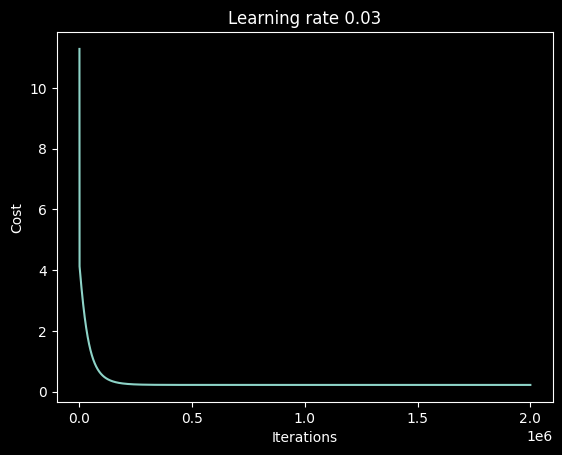

In [19]:
plt.plot(np.arange(0, NUM_ITERATIONS, 1), cost_vec)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.xticks(np.arange(0, NUM_ITERATIONS + 1, 500000))
plt.title("Learning rate " + str(LEARNING_RATE))
plt.show()

Use the fitted parameters to plot the predicted educational expenditure from year 1981 to year 2023.

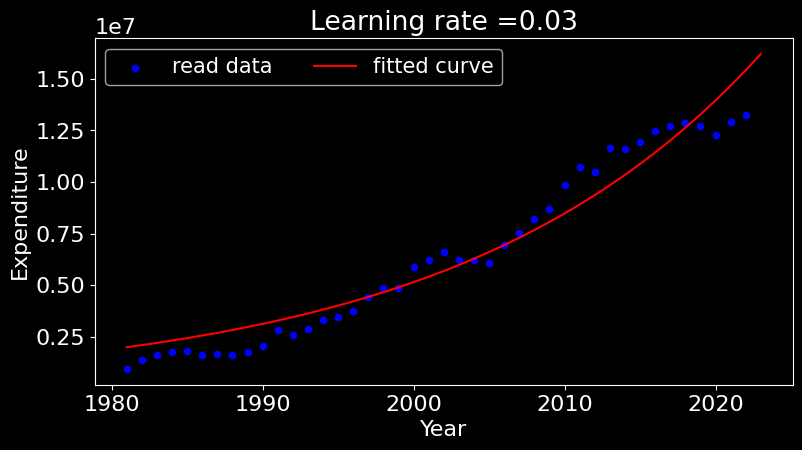

In [22]:
#Extrapoloate until year 2023
ext_years = np.arange(min(years), 2024, 1)
ext_X = np.ones([len(ext_years), 2])
ext_X[:, 1] = ext_years / max_year
pred_y = np.exp(-ext_X @ w)

plt.figure(1, figsize = [9,4.5])
plt.rcParams.update({'font.size': 16})
plt.scatter(years, expenditure, s=20, marker ='o', c='blue', label='read data')
plt.plot(ext_years, pred_y * max_expenditure, c = 'red', label = 'fitted curve')

plt.xlabel('Year')
plt.ylabel('Expenditure')
plt.title('Learning rate =' + str(LEARNING_RATE))
plt.legend(loc = 'upper left', ncol = 3, fontsize = 15)
plt.show()

Using a learning rate of 0.1 and 0.001


Training with Learning Rate: 0.1
  Iteration 0: Cost 14.270524
  Iteration 1000000: Cost 14.276304

Training with Learning Rate: 0.03
  Iteration 0: Cost 11.284558
  Iteration 1000000: Cost 0.223540

Training with Learning Rate: 0.001
  Iteration 0: Cost 11.836357
  Iteration 1000000: Cost 1.939979


C:\Users\Lai Xuan Hua\Desktop\EE2211\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


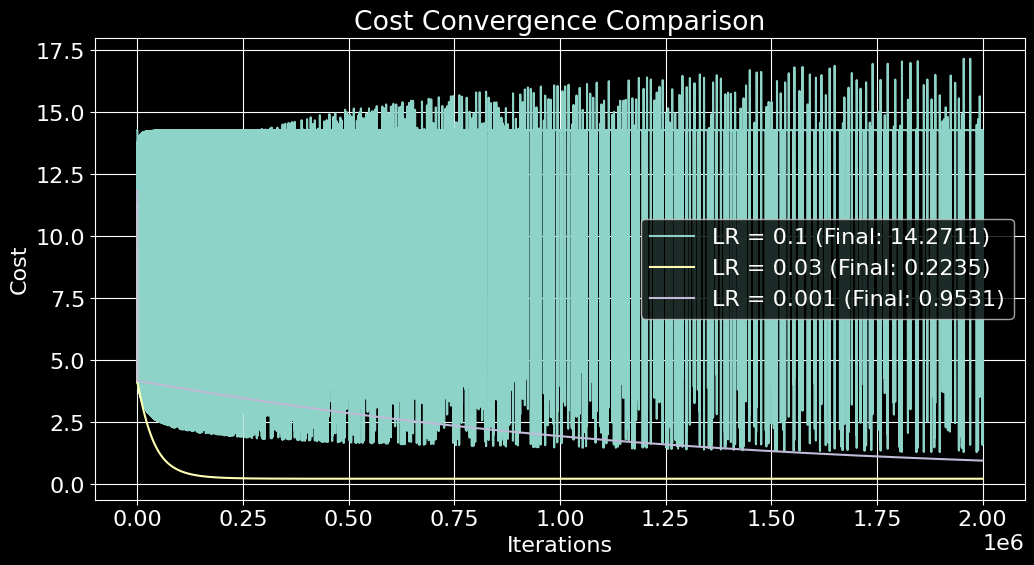

In [23]:
learning_rates = [0.1, 0.03, 0.001]
results = {} # To store cost history and final weights

for lr in learning_rates:
    print(f"\nTraining with Learning Rate: {lr}")
    w = np.zeros(2)
    cost_vec = np.zeros(NUM_ITERATIONS)

    # Pre-calculate initial gradient
    _, cost, grad = training_step(X, w, Y)

    for i in range(NUM_ITERATIONS):
        w = w - lr * grad
        _, cost, grad = training_step(X, w, Y)
        cost_vec[i] = cost

        # Periodic check
        if i % 1000000 == 0:
            print(f"  Iteration {i}: Cost {cost:.6f}")

    # Save results for comparison
    results[lr] = {'costs': cost_vec, 'weights': w, 'final_cost': cost}

# --- 2. Plotting the Comparison ---

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    plt.plot(results[lr]['costs'], label=f'LR = {lr} (Final: {results[lr]["final_cost"]:.4f})')

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()